In [1]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

npmi_long = pd.read_csv("nucleus_npmi_long_min_count_2.csv")

genes = sorted(set(npmi_long["gene_i"]).union(npmi_long["gene_j"]))
gene_to_idx = {g: i for i, g in enumerate(genes)}
G = len(genes)

npmi_mat = np.zeros((G, G), dtype=float)
for row in npmi_long.itertuples(index=False):
    i = gene_to_idx[row.gene_i]
    j = gene_to_idx[row.gene_j]
    npmi_mat[i, j] = row.NPMI
    npmi_mat[j, i] = row.NPMI

In [2]:
T_marker_candidates = ["CD3G", "CD2", "CD52", "CD69",
                       "TRAC", "GZMB", "NKG7", "IL7R"]
M_marker_candidates = ["CD14", "CD68", "CD163", "FCGR3A"]

T_genes = [g for g in T_marker_candidates if g in genes]
M_genes = [g for g in M_marker_candidates if g in genes]

print("T genes used:", T_genes)
print("Myeloid genes used:", M_genes)

T genes used: ['CD3G', 'CD2', 'CD52', 'CD69', 'TRAC', 'GZMB', 'NKG7', 'IL7R']
Myeloid genes used: ['CD14', 'CD68', 'CD163', 'FCGR3A']


In [3]:
np.random.seed(0)

def simulate_fragment(cell_label, frag_label, center3d, n=80, sigma=0.7):
    """Simulate a 3D point cloud (transcripts) for one fragment."""
    pts = center3d + np.random.randn(n, 3) * sigma
    if cell_label == "T":
        genes_choices = T_genes
    else:
        genes_choices = M_genes
    p = np.ones(len(genes_choices), dtype=float)
    p = p / p.sum()
    gene_sample = np.random.choice(genes_choices, size=n, p=p)

    df = pd.DataFrame(pts, columns=["x", "y", "z"])
    df["gene"] = gene_sample
    df["frag_id"] = frag_label
    df["cell_label"] = cell_label
    return df

frags = []

# T cell at z ~ 5, three fragments
T_centers = [
    np.array([0.0, 0.0, 5.0]),
    np.array([3.0, 1.0, 5.5]),
    np.array([1.0, 3.0, 4.5]),
]
for i, c in enumerate(T_centers):
    frags.append(simulate_fragment("T", f"T_frag{i}", c, n=80))

# CD163+ myeloid cell partially under the T cell, overlapping in x,y but lower z
M_centers = [
    np.array([1.5, 1.5, 3.0]),
    np.array([4.0, 2.0, 2.8]),
]
for j, c in enumerate(M_centers):
    frags.append(simulate_fragment("M", f"M_frag{j}", c, n=80))

df_tr = pd.concat(frags, ignore_index=True)
frag_ids = df_tr["frag_id"].unique().tolist()
frag_to_cell = {
    fid: df_tr.loc[df_tr["frag_id"] == fid, "cell_label"].iloc[0]
    for fid in frag_ids
}
print("Fragments:", frag_ids)
print("Fragment → cell_label:", frag_to_cell)


Fragments: ['T_frag0', 'T_frag1', 'T_frag2', 'M_frag0', 'M_frag1']
Fragment → cell_label: {'T_frag0': 'T', 'T_frag1': 'T', 'T_frag2': 'T', 'M_frag0': 'M', 'M_frag1': 'M'}


In [4]:
col_idx = np.arange(G) 
n_frag = len(frag_ids)
M = np.zeros((n_frag, G), dtype=int)

for i, fid in enumerate(frag_ids):
    gset = df_tr.loc[df_tr["frag_id"] == fid, "gene"].unique()
    for g in gset:
        M[i, gene_to_idx[g]] = 1

In [5]:
M

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 366))

In [6]:
def compute_purity_conflict_per_cc(M, npmi_mat, col_idx, purity_threshold=0.05):
    """
    Computes purity & conflict for every fragment, INCLUDING singlets/doublets.

    For k = 1:
        purity = 0
        conflict = 0
    For k >= 2:
        purity = frac(NPMI > threshold)
        conflict = mean(|negative NPMI|)
    """

    n_cells = M.shape[0]
    purity = np.zeros(n_cells)
    conflict = np.zeros(n_cells)

    for i in range(n_cells):
        present = np.where(M[i] == 1)[0]
        k = len(present)

        # ---------- Singlets ----------
        if k == 1:
            purity[i] = 0.0
            conflict[i] = 0.0
            continue

        # ---------- Doublets or more ----------
        gi = col_idx[present]
        sub = npmi_mat[np.ix_(gi, gi)]

        vals = sub[np.triu_indices_from(sub, k=1)]
        if len(vals) == 0:
            purity[i] = 0.0
            conflict[i] = 0.0
            continue

        purity[i] = np.mean(vals > purity_threshold)

        neg = -vals[vals < 0]
        K = k * (k - 1) / 2
        conflict[i] = neg.sum() / K if K > 0 else 0.0

    return purity, conflict


In [7]:
def compute_deltaC_stitch(G_frag, M, npmi_mat, col_idx,
                          purity_threshold=0.05,
                          penalize_simplicity=True):
    """
    Computes ΔC for stitching.

    Normal stitching:
        ΔC = C_union - max(C_u, C_v)

    With simplicity penalty:
        ΔC = C_union - 1/n_union - max(C_u - 1/n_u, C_v - 1/n_v)
    """

    purity, conflict = compute_purity_conflict_per_cc(
        M, npmi_mat, col_idx, purity_threshold
    )
    C_cell = purity - conflict

    # gene counts for penalty
    n_genes = np.sum(M == 1, axis=1)

    dC = {}

    for u, v, data in G_frag.edges(data=True):

        # skip missing
        if np.isnan(C_cell[u]) or np.isnan(C_cell[v]):
            data["deltaC"] = np.nan
            dC[(u, v)] = np.nan
            continue

        # union genes
        present_union = np.where((M[u] == 1) | (M[v] == 1))[0]
        k = len(present_union)

        gi = col_idx[present_union]

        if k < 2:
            # even union is singlet → C=0
            C_union = 0.0
        else:
            sub = npmi_mat[np.ix_(gi, gi)]
            vals = sub[np.triu_indices_from(sub, k=1)]
            purity_union = np.mean(vals > purity_threshold)

            neg = -vals[vals < 0]
            K = k * (k - 1) / 2
            conflict_union = neg.sum() / K if K > 0 else 0.0

            C_union = purity_union - conflict_union

        # ----------------------------
        # ----- Simplicity penalty ----
        # ----------------------------
        if penalize_simplicity:
            nu = n_genes[u] if n_genes[u] > 0 else 1
            nv = n_genes[v] if n_genes[v] > 0 else 1
            nu_union = n_genes[u] + n_genes[v]

            C_u_adj = C_cell[u] - 1/nu
            C_v_adj = C_cell[v] - 1/nv
            C_sep = max(C_u_adj, C_v_adj)

            deltaC = C_union - (1/nu_union) - C_sep

        else:
            C_sep = max(C_cell[u], C_cell[v])
            deltaC = C_union - C_sep

        data["deltaC"] = float(deltaC)
        dC[(u, v)] = float(deltaC)

    return dC, C_cell, purity, conflict


In [8]:
centroids = []
for fid in frag_ids:
    sub = df_tr[df_tr["frag_id"] == fid]
    centroids.append(sub[["x", "y"]].mean().values)
centroids = np.vstack(centroids)

tri = Delaunay(centroids)
edges = set()
for simplex in tri.simplices:
    for i in range(3):
        for j in range(i + 1, 3):
            u, v = sorted((simplex[i], simplex[j]))
            edges.add((u, v))

G_frag = nx.Graph()
for i, fid in enumerate(frag_ids):
    G_frag.add_node(i, frag_id=fid, cell_label=frag_to_cell[fid])

for u, v in edges:
    dist = float(np.linalg.norm(centroids[u] - centroids[v]))
    G_frag.add_edge(u, v, dist=dist)

print("Delaunay edges:", list(G_frag.edges()))

Delaunay edges: [(0, np.int32(1)), (0, np.int32(3)), (0, np.int32(2)), (1, np.int32(4)), (1, np.int32(3)), (2, np.int32(4)), (2, np.int32(3)), (3, np.int32(4))]


In [9]:
dC, C_cell, purity, conflict = compute_deltaC_stitch(
    G_frag, M, npmi_mat, col_idx, purity_threshold=0.05
)

print("\nPer-fragment C_cell (purity - conflict):")
for i, fid in enumerate(frag_ids):
    print(f"{fid:8s} ({frag_to_cell[fid]}): C = {C_cell[i]:.3f}")

print("\nEdges with ΔC and true cell labels:")
for (u, v), dc in dC.items():
    cell_u = frag_to_cell[frag_ids[u]]
    cell_v = frag_to_cell[frag_ids[v]]
    print(
        f"Edge {frag_ids[u]}-{frag_ids[v]} ({cell_u}-{cell_v}): "
        f"ΔC = {dc:.3f}"
    )


Per-fragment C_cell (purity - conflict):
T_frag0  (T): C = 1.000
T_frag1  (T): C = 1.000
T_frag2  (T): C = 1.000
M_frag0  (M): C = 1.000
M_frag1  (M): C = 1.000

Edges with ΔC and true cell labels:
Edge T_frag0-T_frag1 (T-T): ΔC = 0.062
Edge T_frag0-M_frag0 (T-M): ΔC = -0.384
Edge T_frag0-T_frag2 (T-T): ΔC = 0.062
Edge T_frag1-M_frag1 (T-M): ΔC = -0.384
Edge T_frag1-M_frag0 (T-M): ΔC = -0.384
Edge T_frag2-M_frag1 (T-M): ΔC = -0.384
Edge T_frag2-M_frag0 (T-M): ΔC = -0.384
Edge M_frag0-M_frag1 (M-M): ΔC = 0.125


In [10]:
# keep only edges with ΔC >= 0 as "stitchable"
G_pos = nx.Graph()
for u, v, data in G_frag.edges(data=True):
    if data.get("deltaC", -np.inf) >= 0:
        G_pos.add_edge(u, v)

# connected components = stitched cells
stitched_labels = {}
for comp_idx, comp in enumerate(nx.connected_components(G_pos)):
    for node in comp:
        stitched_labels[node] = comp_idx

# fragments that are isolated (no ΔC >= 0 edge) get their own ID
next_id = max(stitched_labels.values(), default=-1) + 1
for node in G_frag.nodes():
    if node not in stitched_labels:
        stitched_labels[node] = next_id
        next_id += 1

print("\nStitched groups (fragment → stitched_cell_id):")
for i, fid in enumerate(frag_ids):
    print(fid, "→", stitched_labels[i])

# Map stitched labels back to each transcript
frag_to_stitched = {frag_ids[i]: stitched_labels[i] for i in range(n_frag)}
df_tr["stitched_id"] = df_tr["frag_id"].map(frag_to_stitched)



Stitched groups (fragment → stitched_cell_id):
T_frag0 → 0
T_frag1 → 0
T_frag2 → 0
M_frag0 → 1
M_frag1 → 1


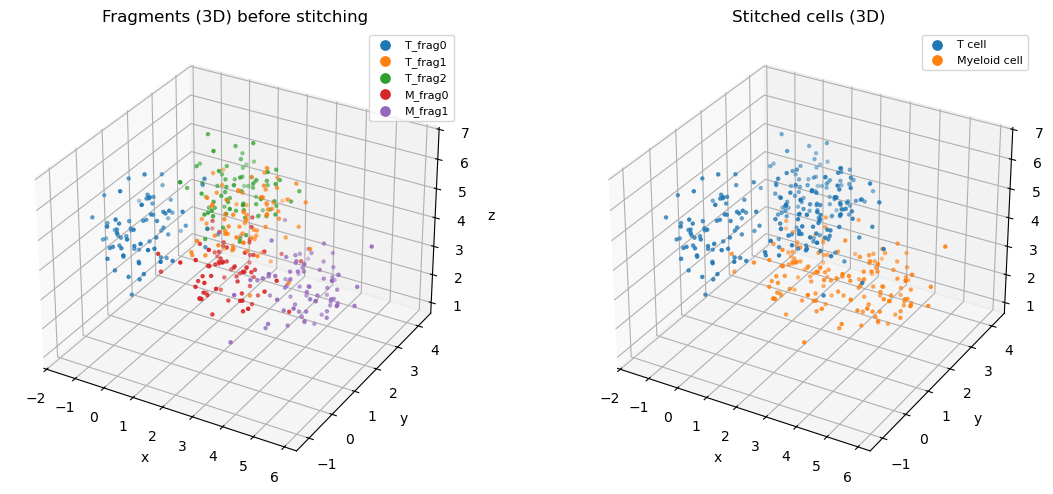

In [11]:
fig = plt.figure(figsize=(12, 5))

# ---- Mapping from stitched_id to cell type ----
stitched_label_map = {
    0: "T cell",
    1: "Myeloid cell"
}

# ---------- Before stitching ----------
ax3d_1 = fig.add_subplot(1, 2, 1, projection="3d")
for fid in frag_ids:
    sub = df_tr[df_tr["frag_id"] == fid]
    ax3d_1.scatter(sub["x"], sub["y"], sub["z"], s=5, label=fid)

ax3d_1.set_title("Fragments (3D) before stitching")
ax3d_1.set_xlabel("x")
ax3d_1.set_ylabel("y")
ax3d_1.set_zlabel("z")
ax3d_1.legend(markerscale=3, fontsize=8)

# ---------- After stitching ----------
ax3d_2 = fig.add_subplot(1, 2, 2, projection="3d")
for stitched_id in sorted(df_tr["stitched_id"].unique()):
    sub = df_tr[df_tr["stitched_id"] == stitched_id]

    label = stitched_label_map.get(
        stitched_id, f"cell{stitched_id}"
    )

    ax3d_2.scatter(
        sub["x"],
        sub["y"],
        sub["z"],
        s=5,
        label=label
    )

ax3d_2.set_title("Stitched cells (3D)")
ax3d_2.set_xlabel("x")
ax3d_2.set_ylabel("y")
ax3d_2.set_zlabel("z")
ax3d_2.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(f"3D_simulation.png", dpi=300)
plt.show()


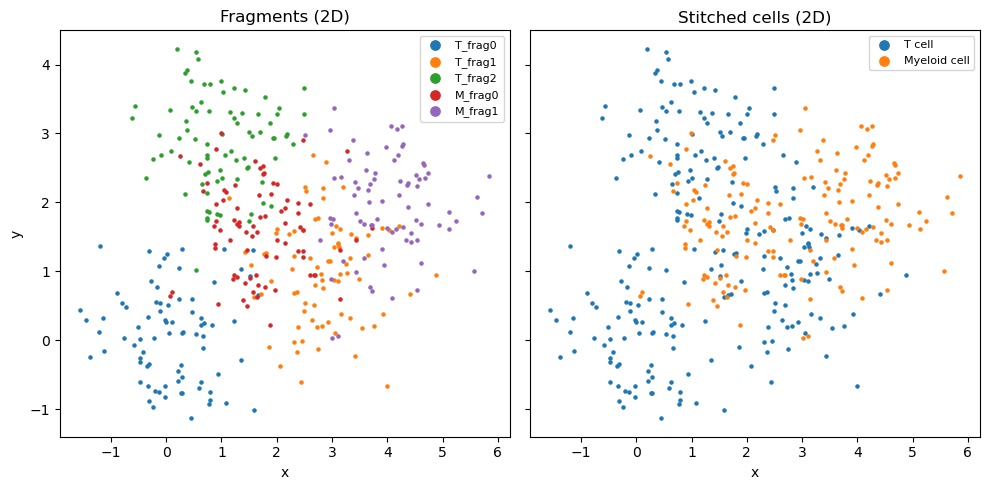

In [12]:
fig2, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# ---- Mapping from stitched_id to cell type ----
stitched_label_map = {
    0: "T cell",
    1: "Myeloid cell"
}

# ---------- Fragments (2D) ----------
ax_xy_1 = axes[0]
for fid in frag_ids:
    sub = df_tr[df_tr["frag_id"] == fid]
    ax_xy_1.scatter(sub["x"], sub["y"], s=5, label=fid)

ax_xy_1.set_title("Fragments (2D)")
ax_xy_1.set_xlabel("x")
ax_xy_1.set_ylabel("y")
ax_xy_1.legend(markerscale=3, fontsize=8)

# ---------- Stitched cells (2D) ----------
ax_xy_2 = axes[1]
for stitched_id in sorted(df_tr["stitched_id"].unique()):
    sub = df_tr[df_tr["stitched_id"] == stitched_id]

    # Use mapped label if available, else default
    label = stitched_label_map.get(stitched_id, f"cell{stitched_id}")

    ax_xy_2.scatter(sub["x"], sub["y"], s=5, label=label)

ax_xy_2.set_title("Stitched cells (2D)")
ax_xy_2.set_xlabel("x")
ax_xy_2.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(f"2D_simulation.png", dpi=300)
plt.show()


In [17]:
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

def plot_3d_hulls_and_edges(df_tr, frag_ids, G_frag, title="Fragment hulls + Delaunay edges"):

    # -------- Compute centroids once --------
    centroids = {
        fid: df_tr[df_tr["frag_id"] == fid][["x","y","z"]].mean().values
        for fid in frag_ids
    }

    # -------- Setup 3 subplots with 3 viewing angles --------
    fig = plt.figure(figsize=(18, 8))
    axs = [fig.add_subplot(1, 3, i+1, projection="3d") for i in range(3)]
    views = [(20, 30), (20, 110), (60, 30)]

    # color map
    cmap = plt.get_cmap("tab10")
    color_map = {fid: cmap(i % 10) for i, fid in enumerate(frag_ids)}

    for ax, view in zip(axs, views):

        # ======== Draw convex hulls =========
        for i, fid in enumerate(frag_ids):

            pts = df_tr[df_tr["frag_id"] == fid][["x","y","z"]].values
            if len(pts) < 4:
                continue

            try:
                hull = ConvexHull(pts)
            except:
                continue

            # draw triangular faces
            for simplex in hull.simplices:
                tri = pts[simplex]
                ax.plot_trisurf(
                    tri[:,0], tri[:,1], tri[:,2],
                    color=color_map[fid],
                    alpha=0.05,               # more transparent
                    edgecolor='k',
                    linewidth=0.3
                )

            # ---- Label centroid with larger bold text ----
            cx,cy,cz = centroids[fid]
            ax.text(cx, cy, cz, str(fid),
                    fontsize=14, color="black",
                    fontweight="bold")
            
        # --- graph node → frag_id mapping ---
        node_to_fid = {i: fid for i, fid in enumerate(frag_ids)}

        # ======== Draw Delaunay / fragment graph edges ========
        for u, v, data in G_frag.edges(data=True):

            fid_u = node_to_fid[u]
            fid_v = node_to_fid[v]

            cu = centroids[fid_u]
            cv = centroids[fid_v]

            dc = data.get("deltaC", np.nan)

            # Use colors to emphasize stitching decision:
            # green = potential stitch, red = rejected
            edge_color = "green" if dc >= 0 else "red"

            ax.plot(
                [cu[0], cv[0]],
                [cu[1], cv[1]],
                [cu[2], cv[2]],
                color=edge_color,
                linewidth=2
            )
            
            # ΔC label mid-edge
            mx, my, mz = (cu + cv) / 2
            ax.text(mx, my, mz + 0.2,
                    f"{dc:.2f}",
                    fontsize=14,
                    color=edge_color,
                    horizontalalignment='center',
                    verticalalignment='center')
        # formatting
        ax.set_title(f"{title}\nView: elev={view[0]}, azim={view[1]}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
        ax.view_init(elev=view[0], azim=view[1])

    plt.tight_layout()
    plt.savefig(f"3D_simulation_stitched.png", dpi=300)
    plt.show()


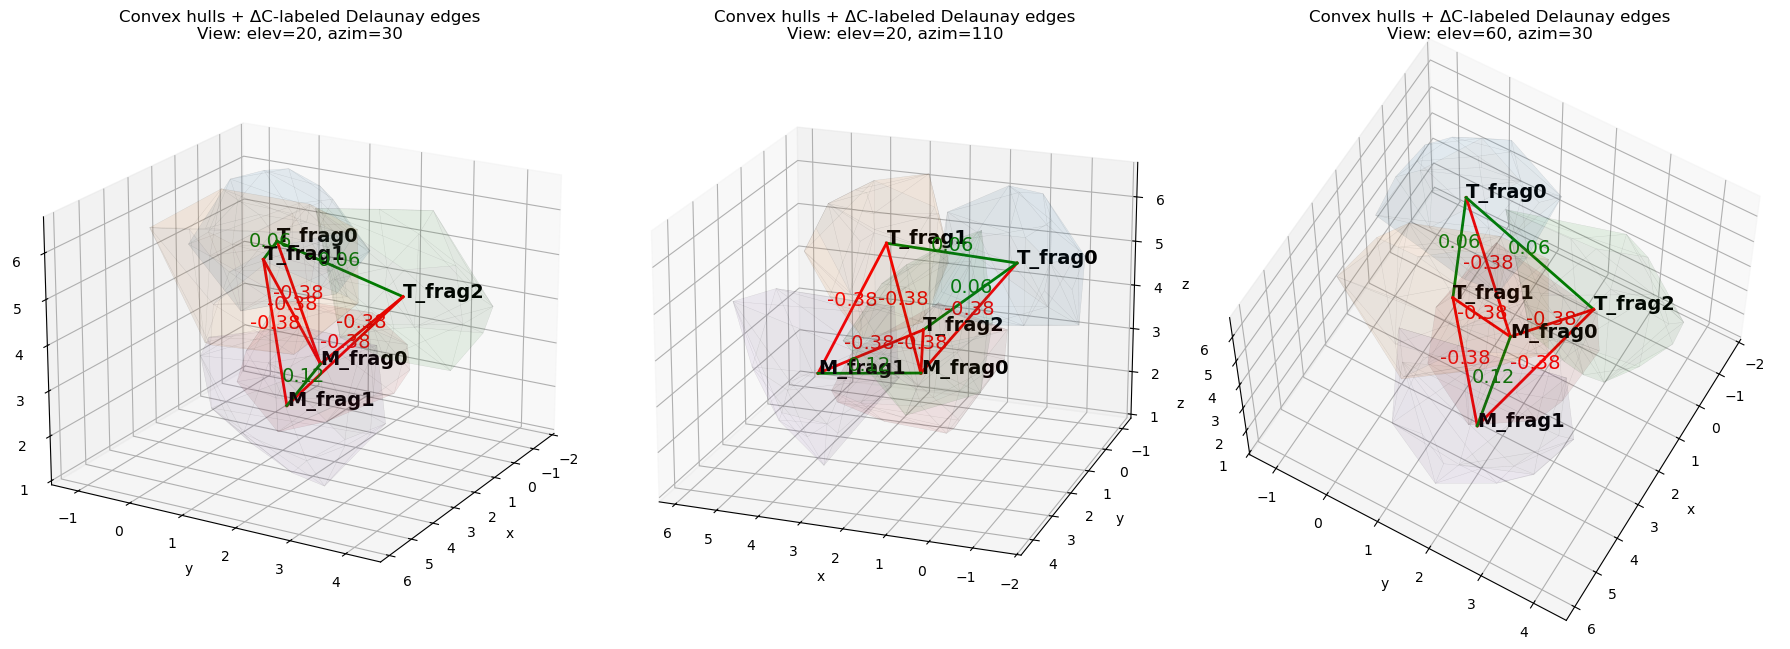

In [18]:
# --- visualization ---
frag_ids = df_tr["frag_id"].unique()
plot_3d_hulls_and_edges(
    df_tr,
    frag_ids,
    G_frag,
    title="Convex hulls + ΔC-labeled Delaunay edges"
)

In [19]:
npmi_long

,gene_i,gene_j,P_i,P_j,P_ij,P_i_given_j,P_j_given_i,PMI,NPMI
0,ABCC9,ABCC9,0.013757,0.013757,0.013757,1.000000,1.000000,4.286177,1.000000
1,ABCC9,ADAMTS12,0.013757,0.005196,0.000401,0.077093,0.029118,1.723427,0.220315
2,ABCC9,ADAMTS16,0.013757,0.000526,0.000080,0.152174,0.005824,2.403445,0.254818
3,ABCC9,ADAMTS3,0.013757,0.000847,0.000114,0.135135,0.008319,2.284697,0.251748
4,ABCC9,ADRA1A,0.013757,0.008550,0.000572,0.066934,0.041597,1.582134,0.211915
...,...,...,...,...,...,...,...,...,...
133951,ZDHHC23,VIP,0.000607,0.001110,0.000000,0.000000,0.000000,NaN,NaN
133952,ZDHHC23,VWC2L,0.000607,0.003411,0.000000,0.000000,0.000000,NaN,NaN
133953,ZDHHC23,WIF1,0.000607,0.000275,0.000000,0.000000,0.000000,NaN,NaN
133954,ZDHHC23,ZBBX,0.000607,0.003640,0.000011,0.003145,0.018868,1.645575,0.144629


In [21]:
# Filter NPMI in (-0.1, -0.05) = weakly anti-correlated (spurious noise)
noise_df = npmi_long[(npmi_long["NPMI"] > -0.1) & (npmi_long["NPMI"] < -0.05)]

# --- Spurious genes for T cells: must be anti-correlated with a T marker ---
noise_T = noise_df[
    (noise_df["gene_i"].isin(T_marker_candidates)) |
    (noise_df["gene_j"].isin(T_marker_candidates))
]

# Extract the partner gene (the one that is NOT the marker)
T_spurious_genes = (
    list(noise_T["gene_i"][~noise_T["gene_i"].isin(T_marker_candidates)]) +
    list(noise_T["gene_j"][~noise_T["gene_j"].isin(T_marker_candidates)])
)

# --- Spurious genes for Myeloid cells ---
noise_M = noise_df[
    (noise_df["gene_i"].isin(M_marker_candidates)) |
    (noise_df["gene_j"].isin(M_marker_candidates))
]

M_spurious_genes = (
    list(noise_M["gene_i"][~noise_M["gene_i"].isin(M_marker_candidates)]) +
    list(noise_M["gene_j"][~noise_M["gene_j"].isin(M_marker_candidates)])
)

# Deduplicate
T_spurious_genes = sorted(set(T_spurious_genes))
M_spurious_genes = sorted(set(M_spurious_genes))

print("Number of T-spurious genes:", len(T_spurious_genes))
print("Number of M-spurious genes:", len(M_spurious_genes))

print("Example T-spurious genes:", T_spurious_genes[:10])
print("Example M-spurious genes:", M_spurious_genes[:10])


Number of T-spurious genes: 131
Number of M-spurious genes: 121
Example T-spurious genes: ['ADAMTS12', 'ADRA1A', 'AKAP12', 'ANGPT1', 'ANO3', 'APLNR', 'AQP4', 'ARHGAP24', 'ATP2C2', 'B4GALNT1']
Example M-spurious genes: ['ADAMTS12', 'ADAMTS16', 'ADAMTS3', 'ADRA1B', 'ANGPT1', 'ANK1', 'ANO3', 'ANXA1', 'APLNR', 'AQP4']


In [22]:
def augment_marker_genes(marker_list, spurious_pool, k_spurious=2, seed=None):
    """
    Take a base marker list and add k_spurious noise genes from spurious_pool.
    No dropping here – just augmentation.

    Returns:
        augmented_list, spurious_added
    """
    rng = np.random.default_rng(seed)

    # Guard: if spurious_pool has fewer than k_spurious
    k_eff = min(k_spurious, len(spurious_pool))
    spurious_added = list(rng.choice(spurious_pool, size=k_eff, replace=False))

    augmented = list(marker_list) + spurious_added
    return augmented, spurious_added
#
T_aug, T_spurious_used = augment_marker_genes(T_marker_candidates, T_spurious_genes, k_spurious=2, seed=0)
M_aug, M_spurious_used = augment_marker_genes(M_marker_candidates, M_spurious_genes, k_spurious=2, seed=1)

print("T augmented markers:", T_aug)
print("M augmented markers:", M_aug)


T augmented markers: ['CD3G', 'CD2', 'CD52', 'CD69', 'TRAC', 'GZMB', 'NKG7', 'IL7R', np.str_('SLIT3'), np.str_('NRN1')]
M augmented markers: ['CD14', 'CD68', 'CD163', 'FCGR3A', np.str_('KLRB1'), np.str_('LHX6')]


In [23]:
def simulate_fragment(
    cell_label,
    frag_label,
    center3d,
    n=80,
    sigma=0.7,
    T_markers_aug=None,
    M_markers_aug=None,
    k_drop=2,
    rng=None,
):
    """
    Simulate a 3D point cloud (transcripts) for one fragment.
    """
    if rng is None:
        rng = np.random.default_rng()

    pts = center3d + rng.normal(size=(n, 3)) * sigma

    if cell_label == "T":
        base_list = list(T_markers_aug)
    else:
        base_list = list(M_markers_aug)

    # ensure keep at least 1 gene
    k_eff = min(k_drop, len(base_list) - 1) if len(base_list) > 1 else 0

    if k_eff > 0:
        dropped = list(rng.choice(base_list, size=k_eff, replace=False))
        final_genes = [g for g in base_list if g not in dropped]
    else:
        dropped = []
        final_genes = base_list

    # print what was used for this connected component
    print(f"\nFragment {frag_label} ({cell_label}):")
    print("  Augmented marker list:", base_list)
    print("  Dropped genes:", dropped)
    print("  Final gene list used:", final_genes)

    # sample transcripts from final gene list
    final_genes = np.array(final_genes)
    p = np.ones(len(final_genes), dtype=float) / len(final_genes)
    gene_sample = rng.choice(final_genes, size=n, p=p)

    df = pd.DataFrame(pts, columns=["x", "y", "z"])
    df["gene"] = gene_sample
    df["frag_id"] = frag_label
    df["cell_label"] = cell_label
    return df


In [27]:
rng = np.random.default_rng(42)

frags = []

# T cell at z ~ 5, three fragments
T_centers = [
    np.array([0.0, 0.0, 5.0]),
    np.array([3.0, 1.0, 5.5]),
    np.array([1.0, 3.0, 4.5]),
]
for i, c in enumerate(T_centers):
    frags.append(
        simulate_fragment(
            "T",
            f"T_frag{i}",
            c,
            n=80,
            sigma=0.7,
            T_markers_aug=T_aug,
            M_markers_aug=M_aug,
            k_drop=1,
            rng=rng,
        )
    )

# CD163+ myeloid cell partially under the T cell, overlapping in x,y but lower z
M_centers = [
    np.array([1.5, 1.5, 3.0]),
    np.array([4.0, 2.0, 2.8]),
]
for j, c in enumerate(M_centers):
    frags.append(
        simulate_fragment(
            "M",
            f"M_frag{j}",
            c,
            n=80,
            sigma=0.7,
            T_markers_aug=T_aug,
            M_markers_aug=M_aug,
            k_drop=1,
            rng=rng,
        )
    )

df_tr = pd.concat(frags, ignore_index=True)

frag_ids = df_tr["frag_id"].unique().tolist()
frag_to_cell = {
    fid: df_tr.loc[df_tr["frag_id"] == fid, "cell_label"].iloc[0]
    for fid in frag_ids
}
print("\nFragments:", frag_ids)
print("Fragment → cell_label:", frag_to_cell)



Fragment T_frag0 (T):
  Augmented marker list: ['CD3G', 'CD2', 'CD52', 'CD69', 'TRAC', 'GZMB', 'NKG7', 'IL7R', np.str_('SLIT3'), np.str_('NRN1')]
  Dropped genes: [np.str_('CD2')]
  Final gene list used: ['CD3G', 'CD52', 'CD69', 'TRAC', 'GZMB', 'NKG7', 'IL7R', np.str_('SLIT3'), np.str_('NRN1')]

Fragment T_frag1 (T):
  Augmented marker list: ['CD3G', 'CD2', 'CD52', 'CD69', 'TRAC', 'GZMB', 'NKG7', 'IL7R', np.str_('SLIT3'), np.str_('NRN1')]
  Dropped genes: [np.str_('CD69')]
  Final gene list used: ['CD3G', 'CD2', 'CD52', 'TRAC', 'GZMB', 'NKG7', 'IL7R', np.str_('SLIT3'), np.str_('NRN1')]

Fragment T_frag2 (T):
  Augmented marker list: ['CD3G', 'CD2', 'CD52', 'CD69', 'TRAC', 'GZMB', 'NKG7', 'IL7R', np.str_('SLIT3'), np.str_('NRN1')]
  Dropped genes: [np.str_('CD52')]
  Final gene list used: ['CD3G', 'CD2', 'CD69', 'TRAC', 'GZMB', 'NKG7', 'IL7R', np.str_('SLIT3'), np.str_('NRN1')]

Fragment M_frag0 (M):
  Augmented marker list: ['CD14', 'CD68', 'CD163', 'FCGR3A', np.str_('KLRB1'), np.str_

In [28]:
# --- Build fragment × gene membership matrix ---
n_frag = len(frag_ids)
M = np.zeros((n_frag, G), dtype=int)
col_idx = np.arange(G)

for i, fid in enumerate(frag_ids):
    gset = df_tr.loc[df_tr["frag_id"] == fid, "gene"].unique()
    for g in gset:
        if g in gene_to_idx:
            M[i, gene_to_idx[g]] = 1

# --- Compute centroids ---
centroids = np.vstack([
    df_tr[df_tr["frag_id"] == fid][["x", "y", "z"]].mean().values
    for fid in frag_ids
])

# --- Delaunay triangulation ---
if len(centroids) < 4:
    tri = Delaunay(centroids[:, :2])
else:
    tri = Delaunay(centroids)

edges = set()
for simplex in tri.simplices:
    for i in range(simplex.shape[0]):
        for j in range(i + 1, simplex.shape[0]):
            edges.add(tuple(sorted((simplex[i], simplex[j]))))

# --- Build graph ---
G_frag = nx.Graph()
for i, fid in enumerate(frag_ids):
    G_frag.add_node(i, frag_id=fid, cell_label=frag_to_cell[fid])

for u, v in edges:
    dist = float(np.linalg.norm(centroids[u] - centroids[v]))
    G_frag.add_edge(u, v, dist=dist)

# --- Compute ΔC ---
dC, C_cell, purity, conflict = compute_deltaC_stitch(
    G_frag, M, npmi_mat, col_idx, purity_threshold=0.05
)

print("\nPer-fragment C_cell (purity - conflict):")
for i, fid in enumerate(frag_ids):
    print(f"{fid:8s} ({frag_to_cell[fid]}): C = {C_cell[i]:.3f}")

print("\nEdges with ΔC and true cell labels:")
for (u, v), dc in dC.items():
    cell_u = frag_to_cell[frag_ids[u]]
    cell_v = frag_to_cell[frag_ids[v]]
    print(
        f"Edge {frag_ids[u]}-{frag_ids[v]} ({cell_u}-{cell_v}): "
        f"ΔC = {dc:.3f}"
    )
    
# --- Keep edges with ΔC ≥ 0 ---
G_pos = nx.Graph()
for u, v, data in G_frag.edges(data=True):
    if data.get("deltaC", -np.inf) >= 0:
        G_pos.add_edge(u, v)

# --- Extract stitched components ---
stitched_labels = {}
for comp_idx, comp in enumerate(nx.connected_components(G_pos)):
    for node in comp:
        stitched_labels[node] = comp_idx

# Add isolated fragments
next_id = max(stitched_labels.values(), default=-1) + 1
for node in G_frag.nodes():
    if node not in stitched_labels:
        stitched_labels[node] = next_id
        next_id += 1

frag_to_stitched = {frag_ids[i]: stitched_labels[i] for i in range(n_frag)}
df_tr["stitched_id"] = df_tr["frag_id"].map(frag_to_stitched)

print("\nStitched groups (fragment → stitched_cell_id):")
for i, fid in enumerate(frag_ids):
    print(fid, "→", stitched_labels[i])


Per-fragment C_cell (purity - conflict):
T_frag0  (T): C = 0.577
T_frag1  (T): C = 0.577
T_frag2  (T): C = 0.572
M_frag0  (M): C = 0.281
M_frag1  (M): C = 0.279

Edges with ΔC and true cell labels:
Edge T_frag0-T_frag1 (T-T): ΔC = 0.089
Edge T_frag0-M_frag1 (T-M): ΔC = -0.151
Edge T_frag0-M_frag0 (T-M): ΔC = -0.154
Edge T_frag0-T_frag2 (T-T): ΔC = 0.089
Edge T_frag1-T_frag2 (T-T): ΔC = 0.089
Edge T_frag1-M_frag1 (T-M): ΔC = -0.186
Edge T_frag1-M_frag0 (T-M): ΔC = -0.189
Edge T_frag2-M_frag1 (T-M): ΔC = -0.149
Edge T_frag2-M_frag0 (T-M): ΔC = -0.151
Edge M_frag0-M_frag1 (M-M): ΔC = 0.200

Stitched groups (fragment → stitched_cell_id):
T_frag0 → 0
T_frag1 → 0
T_frag2 → 0
M_frag0 → 1
M_frag1 → 1


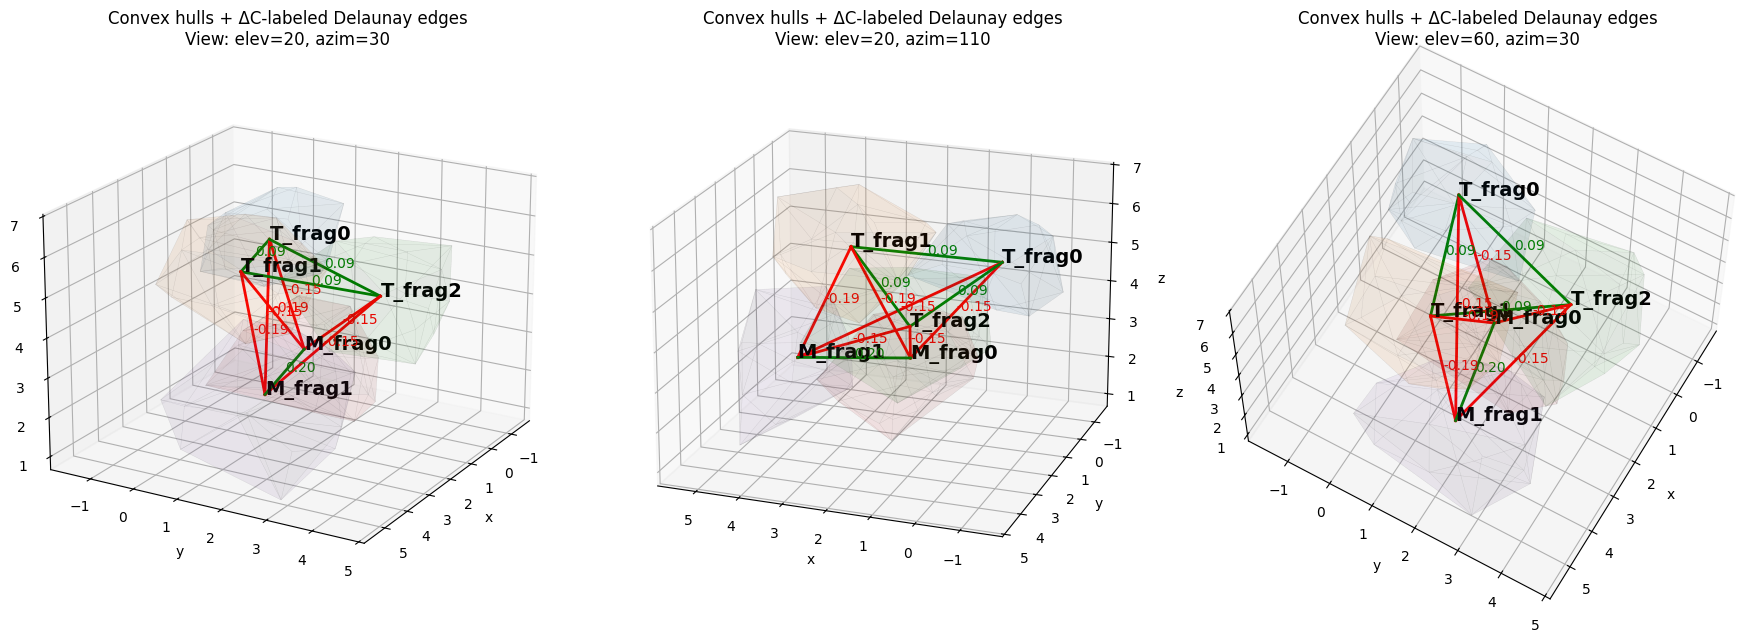

In [29]:
# --- visualization ---
frag_ids = df_tr["frag_id"].unique()
plot_3d_hulls_and_edges(
    df_tr,
    frag_ids,
    G_frag,
    title="Convex hulls + ΔC-labeled Delaunay edges"
)